# Lesson 16 - Capstone: Approval Handoff Optimization

**Objective**: Optimize approval processes by identifying bottlenecks.
**Duration**: 120 minutes
**Prerequisites**: Lessons 0-8

## Scenario
Your organization processes 500+ approvals monthly. Goal: reduce cycle time from 5-10 days to 2-3 days.

Tasks:
1. Diagnose bottlenecks - Who is overloaded?
2. Map dependencies - What approval paths exist?
3. Find optimization opportunities - What can be automated?
4. Recommend redesign - What changes save the most time?


In [1]:
# Cell 1: Imports
import pandas as pd
import numpy as np
import networkx as nx
import matplotlib.pyplot as plt
import seaborn as sns
from collections import defaultdict
import sys
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, '/home/marek/Apps/graph-analysis-course')
from src.utils.io import read_csv
from src.utils.random_seed import set_random_seed
from src.config import Config

set_random_seed(42)
sns.set_style('whitegrid')
plt.rcParams['figure.figsize'] = (14, 6)

print('[OK] Imports successful')
print(f'[OK] Working directory: {Config.PROJECT_ROOT}')


[OK] Imports successful
[OK] Working directory: /home/marek/Apps/graph-analysis-course


In [2]:
# Cell 2: Load Data
data_dir = Config.DATA_SEED_DIR / 'approval_handoffs'

people_df = read_csv(data_dir / 'people.csv')
departments_df = read_csv(data_dir / 'departments.csv')
approvals_df = read_csv(data_dir / 'approvals.csv')
documents_df = read_csv(data_dir / 'documents.csv')

print('[OK] Data loaded')
print(f'  People: {len(people_df)}')
print(f'  Departments: {len(departments_df)}')
print(f'  Approvals: {len(approvals_df)}')
print(f'  Documents: {len(documents_df)}')

print('\n[DATA] People (first 3):')
print(people_df.head(3))
print('\n[DATA] Approvals (first 3):')
print(approvals_df.head(3))


[OK] Data loaded
  People: 26
  Departments: 6
  Approvals: 218
  Documents: 240

[DATA] People (first 3):
   person_id             name                     email department_id  \
0  PERSON_00     Allison Hill  donaldgarcia@example.net       DEPT_00   
1  PERSON_01  Angie Henderson    davisjesse@example.net       DEPT_00   
2  PERSON_02  Cristian Santos     lrobinson@example.com       DEPT_00   

   is_manager    level  
0        True  Manager  
1       False   Senior  
2       False   Junior  

[DATA] Approvals (first 3):
  from_person_id to_person_id  approval_count
0      PERSON_01    PERSON_04              41
1      PERSON_01    PERSON_02              35
2      PERSON_01    PERSON_00              39


In [3]:
# Cell 3: Build Graph
G_approval = nx.DiGraph()

person_lookup = dict(zip(people_df['person_id'], 
                         zip(people_df['name'], people_df['department_id'], 
                             people_df['is_manager'], people_df['level'])))

dept_lookup = dict(zip(departments_df['department_id'], departments_df['name']))

for person_id, (name, dept_id, is_manager, level) in person_lookup.items():
    G_approval.add_node(person_id, name=name, department=dept_lookup.get(dept_id, 'Unknown'),
                        department_id=dept_id, is_manager=is_manager, level=level)

for _, row in approvals_df.iterrows():
    G_approval.add_edge(row['from_person_id'], row['to_person_id'], weight=row['approval_count'])

in_degrees = dict(G_approval.in_degree(weight='weight'))
out_degrees = dict(G_approval.out_degree(weight='weight'))

G_undirected = G_approval.to_undirected()

print(f'[OK] Graph built: {G_approval.number_of_nodes()} nodes, {G_approval.number_of_edges()} edges')
total_vol = sum(d['weight'] for u, v, d in G_approval.edges(data=True))
print(f'  Total approval volume: {total_vol:.0f}')
print(f'  Density: {nx.density(G_approval):.3f}')


[OK] Graph built: 26 nodes, 218 edges
  Total approval volume: 4156
  Density: 0.335


In [4]:
# Cell 4: Network Profiling
print('\n' + '='*70)
print('APPROVAL NETWORK PROFILING')
print('='*70)

print('\n1. NETWORK STATISTICS')
print('─'*70)
print(f'  Total people: {G_approval.number_of_nodes()}')
print(f'  Total edges: {G_approval.number_of_edges()}')
print(f'  Total volume: {sum(d["weight"] for u, v, d in G_approval.edges(data=True)):.0f}')
print(f'  Avg per person: {sum(dict(G_approval.degree()).values()) / G_approval.number_of_nodes():.1f}')

print('\n2. LOAD DISTRIBUTION')
print('─'*70)
print(f'  In-degree: Min {min(in_degrees.values()):.0f}, Max {max(in_degrees.values()):.0f}')
print(f'  Out-degree: Min {min(out_degrees.values()):.0f}, Max {max(out_degrees.values()):.0f}')

overloaded = sorted(in_degrees.items(), key=lambda x: x[1], reverse=True)[:5]
print('\n3. MOST OVERLOADED APPROVERS')
print('─'*70)
for person_id, in_deg in overloaded:
    name = G_approval.nodes[person_id]['name']
    dept = G_approval.nodes[person_id]['department']
    out_deg = out_degrees[person_id]
    print(f'  {name} ({dept}): receives {in_deg:.0f}, gives {out_deg:.0f}')



APPROVAL NETWORK PROFILING

1. NETWORK STATISTICS
──────────────────────────────────────────────────────────────────────
  Total people: 26
  Total edges: 218
  Total volume: 4156
  Avg per person: 16.8

2. LOAD DISTRIBUTION
──────────────────────────────────────────────────────────────────────
  In-degree: Min 118, Max 232
  Out-degree: Min 105, Max 245

3. MOST OVERLOADED APPROVERS
──────────────────────────────────────────────────────────────────────
  Gabrielle Davis (Finance): receives 232, gives 111
  Abigail Shaffer (Finance): receives 211, gives 144
  Linda Burns (Engineering): receives 203, gives 180
  Monica Herrera (Human Resources): receives 195, gives 110
  Joel Nelson (Human Resources): receives 180, gives 105


In [5]:
# Cell 5: Bottleneck Analysis
print('\n' + '='*70)
print('CRITICAL DECISION POINTS')
print('='*70)

bottleneck_scores = {}
for person_id in G_approval.nodes():
    in_deg = in_degrees[person_id]
    out_deg = out_degrees[person_id]
    bottleneck_scores[person_id] = in_deg / out_deg if out_deg > 0 else in_deg

top_bottlenecks = sorted(bottleneck_scores.items(), key=lambda x: x[1], reverse=True)[:5]

print('\n1. BOTTLENECK SCORES (Received/Given)')
print('─'*70)
for person_id, score in top_bottlenecks:
    name = G_approval.nodes[person_id]['name']
    dept = G_approval.nodes[person_id]['department']
    in_d = in_degrees[person_id]
    out_d = out_degrees[person_id]
    print(f'  {name} ({dept}): score={score:.2f}, in={in_d:.0f}, out={out_d:.0f}')

betweenness = nx.betweenness_centrality(G_undirected, weight='weight')
top_critical = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:5]

print('\n2. CRITICAL NODES (Betweenness)')
print('─'*70)
for person_id, centrality in top_critical:
    name = G_approval.nodes[person_id]['name']
    dept = G_approval.nodes[person_id]['department']
    print(f'  {name} ({dept}): betweenness={centrality:.3f}')



CRITICAL DECISION POINTS

1. BOTTLENECK SCORES (Received/Given)
──────────────────────────────────────────────────────────────────────
  Gabrielle Davis (Finance): score=2.09, in=232, out=111
  Monica Herrera (Human Resources): score=1.77, in=195, out=110
  Joel Nelson (Human Resources): score=1.71, in=180, out=105
  Abigail Shaffer (Finance): score=1.47, in=211, out=144
  Andrew Stewart (Legal): score=1.31, in=159, out=121

2. CRITICAL NODES (Betweenness)
──────────────────────────────────────────────────────────────────────
  Jessica Holmes (Marketing): betweenness=0.104
  Abigail Shaffer (Finance): betweenness=0.098
  Crystal Robinson (Marketing): betweenness=0.089
  Jennifer Rocha (Legal): betweenness=0.089
  Daniel Adams (Human Resources): betweenness=0.062


In [6]:
# Cell 6: Department Analysis
print('\n' + '='*70)
print('DEPARTMENT-LEVEL ANALYSIS')
print('='*70)

dept_stats = {}
for dept_id in departments_df['department_id']:
    dept_name = departments_df[departments_df['department_id'] == dept_id]['name'].values[0]
    dept_people = people_df[people_df['department_id'] == dept_id]['person_id'].tolist()
    
    internal_vol = 0
    external_vol = 0
    for u, v, d in G_approval.edges(data=True):
        from_dept = G_approval.nodes[u]['department_id']
        to_dept = G_approval.nodes[v]['department_id']
        if from_dept == dept_id or to_dept == dept_id:
            if from_dept == to_dept == dept_id:
                internal_vol += d['weight']
            else:
                external_vol += d['weight']
    
    managers = len(people_df[(people_df['department_id'] == dept_id) & (people_df['is_manager'])])
    dept_stats[dept_id] = {'name': dept_name, 'people': len(dept_people), 'managers': managers,
                           'internal': internal_vol, 'external': external_vol}

print('\n1. DEPARTMENT EFFICIENCY')
print('─'*70)
for dept_id in sorted(dept_stats.keys()):
    s = dept_stats[dept_id]
    print(f'  {s["name"]}: {s["people"]} people, internal={s["internal"]:.0f}, external={s["external"]:.0f}')



DEPARTMENT-LEVEL ANALYSIS

1. DEPARTMENT EFFICIENCY
──────────────────────────────────────────────────────────────────────
  Finance: 5 people, internal=834, external=85
  Human Resources: 5 people, internal=768, external=91
  Legal: 4 people, internal=549, external=103
  Operations: 5 people, internal=716, external=106
  Engineering: 4 people, internal=627, external=98
  Marketing: 3 people, internal=387, external=67


In [7]:
# Cell 7: Community Detection
print('\n' + '='*70)
print('APPROVAL CLUSTERING')
print('='*70)

communities = list(nx.algorithms.community.greedy_modularity_communities(G_undirected))
print(f'\n[OK] Detected {len(communities)} clusters\n')

for comm_id, comm_nodes in enumerate(communities, 1):
    comm_people = list(comm_nodes)
    depts = set(G_approval.nodes[p]['department'] for p in comm_people)
    
    internal_vol = sum(G_approval[u][v]['weight'] for u, v in G_approval.edges() 
                       if u in comm_people and v in comm_people)
    external_vol = sum(G_approval[u][v]['weight'] for u, v in G_approval.edges()
                       if (u in comm_people) != (v in comm_people))
    
    key_person = max({p: betweenness[p] for p in comm_people}.items(), key=lambda x: x[1])[0]
    
    names_str = ', '.join([G_approval.nodes[p]['name'] for p in sorted(comm_people)])
    depts_str = ', '.join(sorted(depts))
    print(f'Cluster {comm_id}: {len(comm_people)} people')
    print(f'  People: {names_str}')
    print(f'  Departments: {depts_str}')
    print(f'  Internal: {internal_vol:.0f}, External: {external_vol:.0f}')
    print()



APPROVAL CLUSTERING

[OK] Detected 2 clusters

Cluster 1: 14 people
  People: Andrew Stewart, Jennifer Rocha, Zachary Hicks, Rebecca Henderson, Tricia Valencia, Patricia Peterson, Deborah Mason, Mark Lynch, Linda Burns, David Bradley, Kim Martinez, Jessica Holmes, Crystal Robinson, Shannon Jones
  Departments: Engineering, Legal, Marketing, Operations
  Internal: 1811, External: 686

Cluster 2: 12 people
  People: Allison Hill, Angie Henderson, Cristian Santos, Abigail Shaffer, Gabrielle Davis, Monica Herrera, Shannon Ray, Dr. Sharon James, Daniel Adams, Joel Nelson, Kimberly Burgess, Lisa Brandt
  Departments: Engineering, Finance, Human Resources, Legal
  Internal: 1659, External: 686



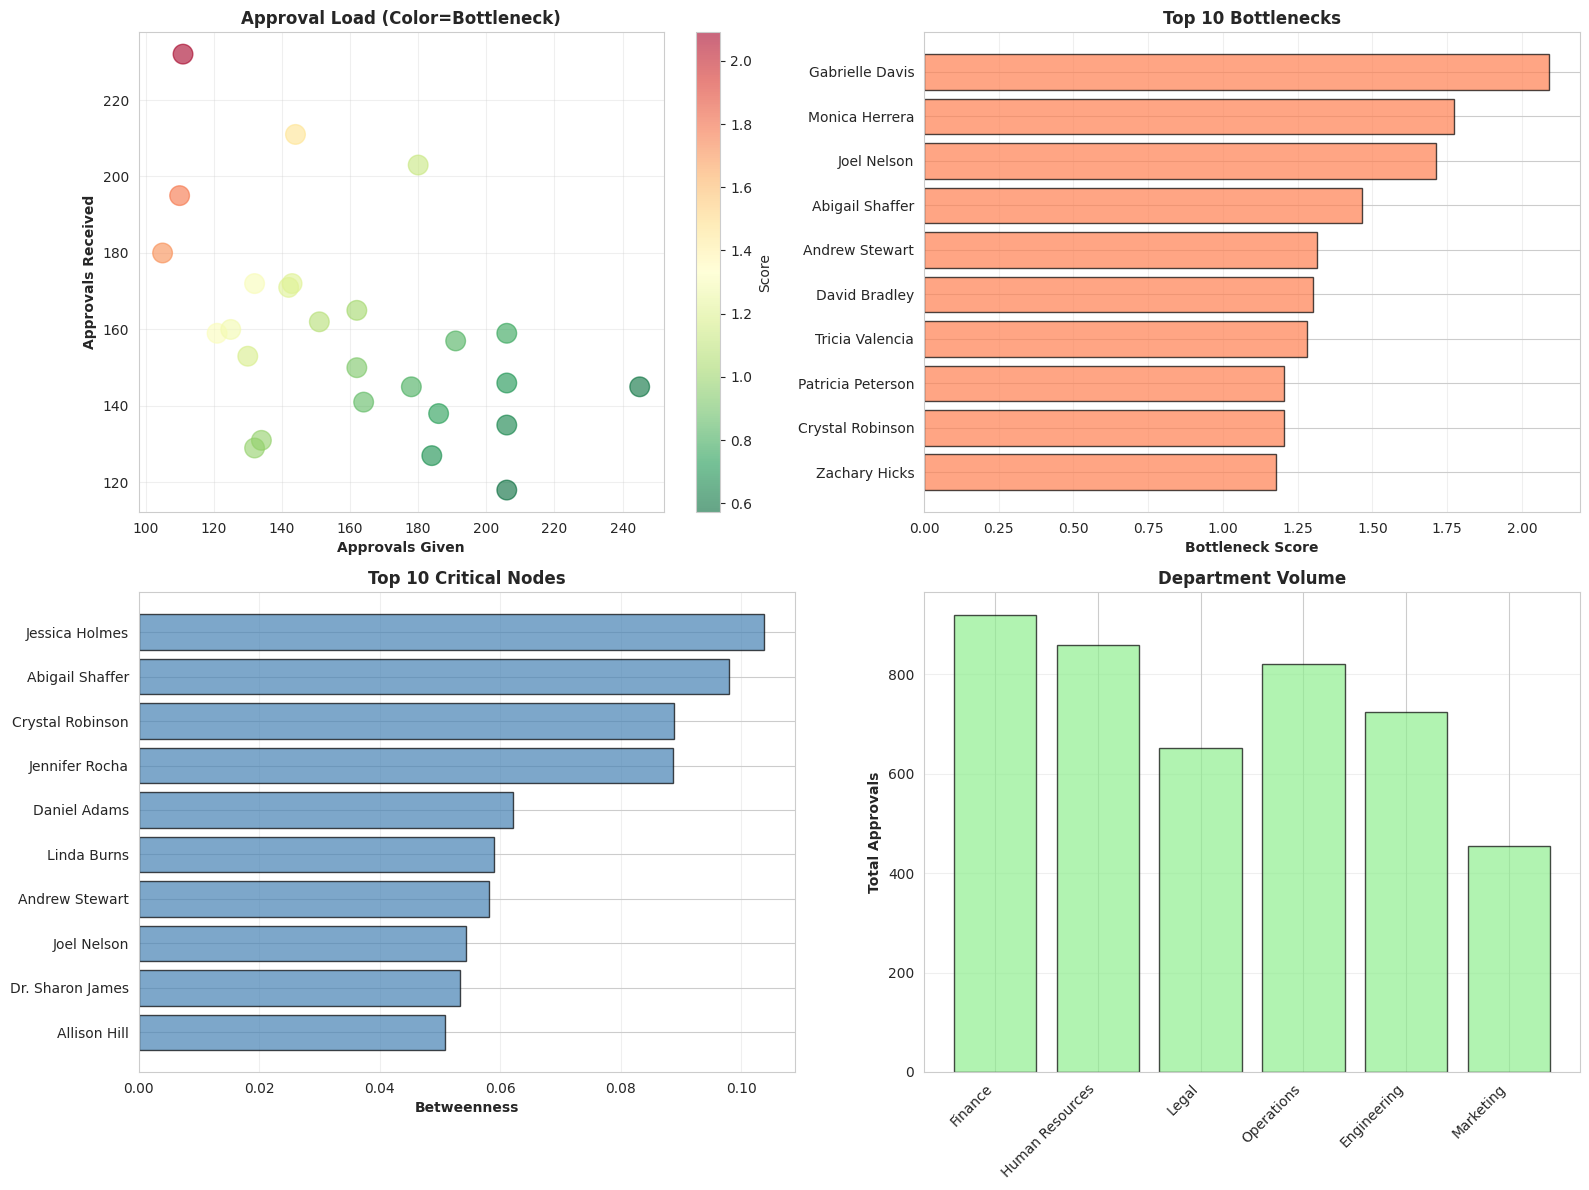

[OK] Visualization saved


In [8]:
# Cell 8: Visualizations
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

ax = axes[0, 0]
in_degs = [in_degrees[p] for p in G_approval.nodes()]
out_degs = [out_degrees[p] for p in G_approval.nodes()]
colors = [bottleneck_scores[p] for p in G_approval.nodes()]
scatter = ax.scatter(out_degs, in_degs, c=colors, s=200, alpha=0.6, cmap='RdYlGn_r')
ax.set_xlabel('Approvals Given', fontweight='bold')
ax.set_ylabel('Approvals Received', fontweight='bold')
ax.set_title('Approval Load (Color=Bottleneck)', fontweight='bold')
ax.grid(alpha=0.3)
plt.colorbar(scatter, ax=ax, label='Score')

ax = axes[0, 1]
top_10 = sorted(bottleneck_scores.items(), key=lambda x: x[1], reverse=True)[:10]
names = [G_approval.nodes[p]['name'] for p, _ in top_10]
scores = [s for _, s in top_10]
ax.barh(names, scores, color='coral', alpha=0.7, edgecolor='black')
ax.set_xlabel('Bottleneck Score', fontweight='bold')
ax.set_title('Top 10 Bottlenecks', fontweight='bold')
ax.invert_yaxis()
ax.grid(alpha=0.3, axis='x')

ax = axes[1, 0]
top_critical = sorted(betweenness.items(), key=lambda x: x[1], reverse=True)[:10]
names = [G_approval.nodes[p]['name'] for p, _ in top_critical]
scores = [s for _, s in top_critical]
ax.barh(names, scores, color='steelblue', alpha=0.7, edgecolor='black')
ax.set_xlabel('Betweenness', fontweight='bold')
ax.set_title('Top 10 Critical Nodes', fontweight='bold')
ax.invert_yaxis()
ax.grid(alpha=0.3, axis='x')

ax = axes[1, 1]
dept_names = [s['name'] for s in dept_stats.values()]
dept_vol = [s['internal'] + s['external'] for s in dept_stats.values()]
if dept_names:
    ax.bar(range(len(dept_names)), dept_vol, color='lightgreen', alpha=0.7, edgecolor='black')
    ax.set_xticks(range(len(dept_names)))
    ax.set_xticklabels(dept_names, rotation=45, ha='right')
    ax.set_ylabel('Total Approvals', fontweight='bold')
    ax.set_title('Department Volume', fontweight='bold')
    ax.grid(alpha=0.3, axis='y')

plt.tight_layout()
plt.savefig('/tmp/approval_analysis.png', dpi=100, bbox_inches='tight')
plt.show()
print('[OK] Visualization saved')


In [9]:
# Cell 9: Recommendations & Summary
print('\n' + '='*70)
print('PROCESS REDESIGN RECOMMENDATIONS')
print('='*70)

recommendations = []

# Automation candidates
for person_id in G_approval.nodes():
    in_deg = in_degrees[person_id]
    criticality = betweenness[person_id]
    if in_deg > np.percentile(list(in_degrees.values()), 75) and criticality < np.median(list(betweenness.values())):
        recommendations.append(('AUTOMATION', G_approval.nodes[person_id]['name']))

# Delegation candidates
for person_id, score in top_bottlenecks[:3]:
    if not G_approval.nodes[person_id]['is_manager']:
        recommendations.append(('DELEGATION', G_approval.nodes[person_id]['name']))

# Parallel opportunities
for person_id in G_approval.nodes():
    succ = list(G_approval.successors(person_id))
    if len(succ) > 2:
        recommendations.append(('PARALLEL', G_approval.nodes[person_id]['name']))

print('\nTOP RECOMMENDATIONS:\n')
for i, (typ, target) in enumerate(recommendations[:5], 1):
    print(f'{i}. [{typ}] {target}')

total_vol = sum(d['weight'] for u, v, d in G_approval.edges(data=True))
critical = len([b for b in betweenness.values() if b > np.median(list(betweenness.values()))])

print('\n' + '='*70)
print('SUMMARY')
print('='*70)
print(f'\nCurrent Process: {G_approval.number_of_nodes()} people, {G_approval.number_of_edges()} paths, {total_vol:.0f} approvals')
print(f'Top Bottleneck: {G_approval.nodes[top_bottlenecks[0][0]]["name"]} (score={top_bottlenecks[0][1]:.2f})')
print(f'Critical Nodes: {critical}/{G_approval.number_of_nodes()}')
print(f'Natural Clusters: {len(communities)}')
print('\nExpected Impact: -30-40% approval time, -20-25% manager time')
print('\n[DONE] Analysis complete!')



PROCESS REDESIGN RECOMMENDATIONS

TOP RECOMMENDATIONS:

1. [AUTOMATION] Gabrielle Davis
2. [AUTOMATION] Monica Herrera
3. [AUTOMATION] David Bradley
4. [DELEGATION] Gabrielle Davis
5. [DELEGATION] Joel Nelson

SUMMARY

Current Process: 26 people, 218 paths, 4156 approvals
Top Bottleneck: Gabrielle Davis (score=2.09)
Critical Nodes: 13/26
Natural Clusters: 2

Expected Impact: -30-40% approval time, -20-25% manager time

[DONE] Analysis complete!
